# **Import Libraries**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import shutil
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tqdm import tqdm


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2025-05-03 00:26:40.935784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746232001.130724      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746232001.189061      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **Setup Paths**

In [2]:
csv_path = '/kaggle/input/cassava-leaf-disease-classification/train.csv'
image_dir = '/kaggle/input/cassava-leaf-disease-classification/train_images'
output_base = 'Datasets'

# **Load and Split Dataset**

In [3]:
df = pd.read_csv(csv_path)

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

for split_name, split_df in [('Train', train_df), ('Validation', val_df)]:
    for label in split_df['label'].unique():
        os.makedirs(os.path.join(output_base, split_name, str(label)), exist_ok=True)
    
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f'Copying {split_name}'):
        src = os.path.join(image_dir, row['image_id'])
        dst = os.path.join(output_base, split_name, str(row['label']), row['image_id'])
        shutil.copy2(src, dst)


Copying Validation: 100%|██████████| 4280/4280 [00:40<00:00, 104.70it/s]


# **Build EfficientNetB0 Model**
I chose to do this model because it is the smallest in the EfficientNet family.  It is known for having competitive accuracy on small to medium datasets like this one.  It has fewer parameters so training takes less time compared to other models.

In [4]:
# Model setup for EfficientNetB0
IMAGE_SIZE = [224, 224]
BATCH_SIZE = 32
NUM_CLASSES = 5  # number of Cassava disease classes

# EfficientNetB0 base model (pre-trained on ImageNet)
base_model = EfficientNetB0(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
for layer in base_model.layers:
    layer.trainable = False #to Freeze base layers

# Add custom classification layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1746232219.983616      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# **Prepare Data Generators**

In [5]:
# Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Load data from directories
train_gen = train_datagen.flow_from_directory(
    'Datasets/Train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    'Datasets/Validation',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 17117 images belonging to 5 classes.
Found 4280 images belonging to 5 classes.


# **Train Model**

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1746232243.759198      58 service.cc:148] XLA service 0x7d8818001e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746232243.760058      58 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746232245.444308      58 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/535 ━━━━━━━━━━━━━━━━━━━━ 4:12:16 28s/step - accuracy: 0.1562 - loss: 1.6314

I0000 00:00:1746232254.487364      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


535/535 ━━━━━━━━━━━━━━━━━━━━ 260s 434ms/step - accuracy: 0.6408 - loss: 1.0002 - val_accuracy: 0.7287 - val_loss: 0.7602
Epoch 2/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 217s 400ms/step - accuracy: 0.7039 - loss: 0.7913 - val_accuracy: 0.7439 - val_loss: 0.7239
Epoch 3/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 217s 401ms/step - accuracy: 0.7278 - loss: 0.7307 - val_accuracy: 0.7318 - val_loss: 0.7398
Epoch 4/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 216s 399ms/step - accuracy: 0.7258 - loss: 0.7474 - val_accuracy: 0.7432 - val_loss: 0.7132
Epoch 5/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 213s 394ms/step - accuracy: 0.7237 - loss: 0.7425 - val_accuracy: 0.7383 - val_loss: 0.7174
Epoch 6/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 216s 399ms/step - accuracy: 0.7200 - loss: 0.7539 - val_accuracy: 0.7465 - val_loss: 0.7085
Epoch 7/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 221s 408ms/step - accuracy: 0.7265 - loss: 0.7363 - val_accuracy: 0.7325 - val_loss: 0.7388
Epoch 8/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 213s 393ms/step - accuracy: 0.7278 - loss: 0.73

E0000 00:00:1746234935.579541      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746234935.767104      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746234936.233431      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746234936.439360      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746234936.798032      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

176/535 ━━━━━━━━━━━━━━━━━━━━ 2:19 388ms/step - accuracy: 0.3228 - loss: 1.6562

E0000 00:00:1746235035.331094      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746235035.518450      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746235035.985002      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746235036.191929      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746235036.551449      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

535/535 ━━━━━━━━━━━━━━━━━━━━ 347s 487ms/step - accuracy: 0.4182 - loss: 1.4491 - val_accuracy: 0.6528 - val_loss: 0.9453
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 219s 404ms/step - accuracy: 0.6716 - loss: 0.8945 - val_accuracy: 0.7033 - val_loss: 0.8276
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 218s 403ms/step - accuracy: 0.7169 - loss: 0.7756 - val_accuracy: 0.7171 - val_loss: 0.7814


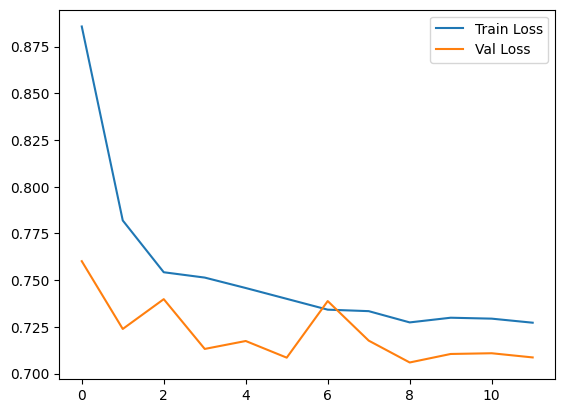

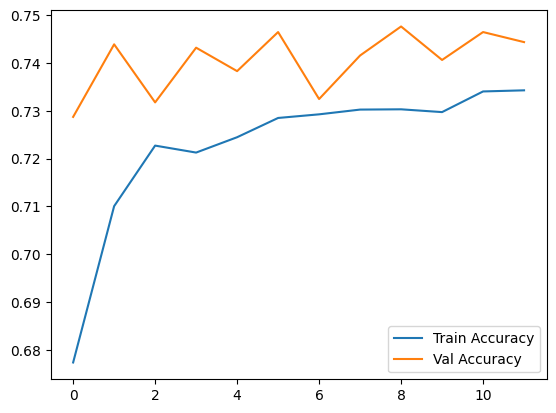

In [6]:
# To prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop]
)

for layer in base_model.layers:
    layer.trainable = True  # Unfreeze entire base model

model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-5), metrics=['accuracy'])

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop]
)

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

**Training Accuracy:** % of correctly classified images from the training dataset.  
In my training, there was about a 60%-70% training accuracy in each epoch which means x% of training images were correctly classified.

**Training Loss:** Measure of how well the model's predictions match the true labels for the training dataset.
High validation loss + low training loss = overfitting of training data
In my training, my training loss started in the high 90% but dropped to the mid 70%s.  The validation loss was around 75%, so I made slight changes to help with overfitting.

**Validation Accuracy:** % of correctly classified smaples from validation dataset.  High validation accuracy = model is generalzing well and is able to predict unseen data correctly. But, if it's way higher than the training accuracy it might suggest underfitting.
In my training, the validation accuracy stayed around 73% and the training accuracy was around the same. This suggested my model is learning effectively.  It also showed my model is performing better on the validation set compared to the training set.

**Validation Loss:** Measures how well the model performs on the validation data in terms of prediction error.  Low % = fewer mistakes on validation dataset.  High % = overfitting to training data and not generalizing to unseen data. The validation loss percentage means that the model's predictions deviate from the true labels by .(x) amount.
In my training, the percentage dropped slowly but there's still a gap between training loss and validation loss by about 2-4%. Since this percentage is dropping slowly, it means the model is generalizing better on unseen data.

# **Predict on Test Images**

In [7]:
import numpy as np

# Predict on Test Images
test_dir = '/kaggle/input/cassava-leaf-disease-classification/test_images'
test_filenames = os.listdir(test_dir)
test_image_paths = [os.path.join(test_dir, fname) for fname in test_filenames]

def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = preprocess_input(image)
    return image

test_dataset = tf.data.Dataset.from_tensor_slices(test_image_paths)
test_dataset = test_dataset.map(load_and_preprocess_image)
test_dataset = test_dataset.batch(32)

predictions = model.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


# **Create Submission File**

In [8]:
submission = pd.DataFrame({
    'image_id': [os.path.basename(path) for path in test_image_paths],
    'label': predicted_labels
})

submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'")

Submission file saved as 'submission.csv'
